# Mosaic Holotomography — Synthetic Data Generation

3 horizontal fields of view, 900 angles × 180°.
One scan at the centre, one shifted −0.8 FOV (left), one +0.8 FOV (right).

In [1]:
import os
os.environ['CUDA_HOME'] = '/local/nvidia/hpc_sdk/Linux_x86_64/26.1/cuda/13.1'

import numpy as np
import cupy as cp
import h5py
from scipy.fft import fftn, ifftn, fftshift, fft2, ifft2
import scipy.ndimage as ndimage
from mpi4py import MPI
from types import SimpleNamespace

from holotomocupy.rec_mpi import Rec
from holotomocupy.utils import *

cuFFTDx (mathDX) available — using fast cuFFTDx propagator.


## Acquisition Parameters

In [ ]:
n      = 128                                           # detector size (pixels)
ntheta = 360                                           # projection angles per scan
ndist  = 4                                             # propagation distances

nobj  = 512                                           # object x,y extent (pixels)
nzobj = 192                                            # object z extent  (pixels)

energy                  = 17.1                         # X-ray energy (keV)
detector_pixelsize      = 1.4760147601476e-6 * 2 * 8  # effective pixel size (m)
focustodetectordistance = 1.217                        # focus-to-detector distance (m)
z1 = np.array([5.110, 5.464, 6.879, 9.817]) * 1e-3   # sample-to-focus distances (m)

# Three scans: left, centre, right
shift_fov   = 0.8
axis_shifts = np.array([-shift_fov * n, 0.0, shift_fov * n], dtype='float32')
scan_labels = ['left', 'center', 'right']

os.makedirs('data', exist_ok=True)

## Synthetic Phantom Object

Wire-frame cube generated at n×n×n, then scaled to nzobj×nobj×nobj
with nearest-neighbour zoom (order=0).

In [3]:
def _draw_frame_edges_inplace(cube, p1, p2):
    cube[p1:p2, p1, p1] = 1; cube[p1:p2, p1, p2] = 1
    cube[p1:p2, p2, p1] = 1; cube[p1:p2, p2, p2] = 1
    cube[p1, p1:p2, p1] = 1; cube[p1, p1:p2, p2] = 1
    cube[p2, p1:p2, p1] = 1; cube[p2, p1:p2, p2] = 1
    cube[p1, p1, p1:p2] = 1; cube[p1, p2, p1:p2] = 1
    cube[p2, p1, p1:p2] = 1; cube[p2, p2, p1:p2] = 1

def rotate3d_once(vol, ang_xy_deg=28, ang_xz_deg=45, order=1):
    a = np.deg2rad(ang_xy_deg)
    b = np.deg2rad(ang_xz_deg)
    Rz = np.array([[ np.cos(a), -np.sin(a), 0],
                   [ np.sin(a),  np.cos(a), 0],
                   [ 0,          0,         1]], dtype=np.float64)
    Ry = np.array([[ np.cos(b), 0, np.sin(b)],
                   [ 0,         1, 0        ],
                   [-np.sin(b), 0, np.cos(b)]], dtype=np.float64)
    R = Ry @ Rz
    A = np.linalg.inv(R)
    center = (np.array(vol.shape) - 1) / 2.0
    offset = center - A @ center
    return ndimage.affine_transform(vol, A, offset=offset, order=order,
                                    mode='constant', cval=0.0, prefilter=(order > 1))

def gen_object(n, delta, beta):
    obj = np.zeros((n, n, n), dtype=np.float32)
    rr   = (np.ones(8) * n * 0.3).astype(np.int32)
    amps = np.array([3, -3, 1, 3, -4, 1, 4], dtype=np.float32)
    dil  = (np.array([33, 28, 25, 21, 16, 10, 3], dtype=np.float32) / 256.0) * n

    ax = np.arange(-n//2, n//2, dtype=np.float32)
    x, y, z = np.meshgrid(ax, ax, ax, indexing='ij')
    r2 = x*x + y*y + z*z
    del x, y, z

    fcirc_list = []
    for d in dil:
        circ = (r2 < (d*d)).astype(np.float32, copy=False)
        fcirc_list.append(fftn(fftshift(circ), workers=-1).astype(np.complex64, copy=False))

    cube = np.zeros((n, n, n), dtype=np.float32)
    fcube_list = []
    for kk in range(len(amps)):
        cube.fill(0.0)
        r = int(rr[kk])
        p1 = n//2 - r//2
        p2 = n//2 + r//2
        _draw_frame_edges_inplace(cube, p1, p2)
        fcube_list.append(fftn(fftshift(cube), workers=-1).astype(np.complex64, copy=False))

    work = np.empty((n, n, n), dtype=np.complex64)
    for kk, a in enumerate(amps):
        np.multiply(fcube_list[kk], fcirc_list[kk], out=work)
        conv = fftshift(ifftn(work, workers=-1)).real
        obj += a * (conv > 1.0)

    obj = rotate3d_once(obj, 28, 45, order=1)
    obj = np.roll(obj, -15*n//256, axis=2)
    obj = np.roll(obj, -10*n//256, axis=1)
    np.maximum(obj, 0, out=obj)

    v = np.arange(-n//2, n//2, dtype=np.float32) / n
    vx, vy, vz = np.meshgrid(v, v, v, indexing='ij')
    filt = fftshift(np.exp(-3.0 * (vx*vx + vy*vy + vz*vz)).astype(np.float32))
    obj = ifftn(fftn(obj) * filt).real
    obj[obj < 0] = 0
    return (obj * (-delta + 1j*beta)).astype(np.complex64, copy=False)

Generating base cube 128^3 ...
Zooming to 192×512×512 with factors (1.5, 4.0, 4.0) (order=0) ...


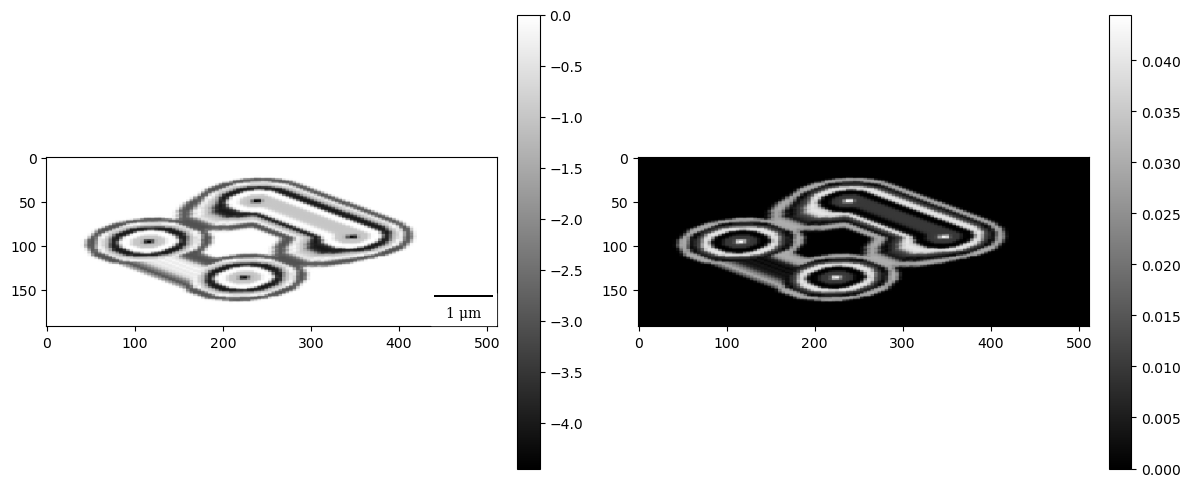

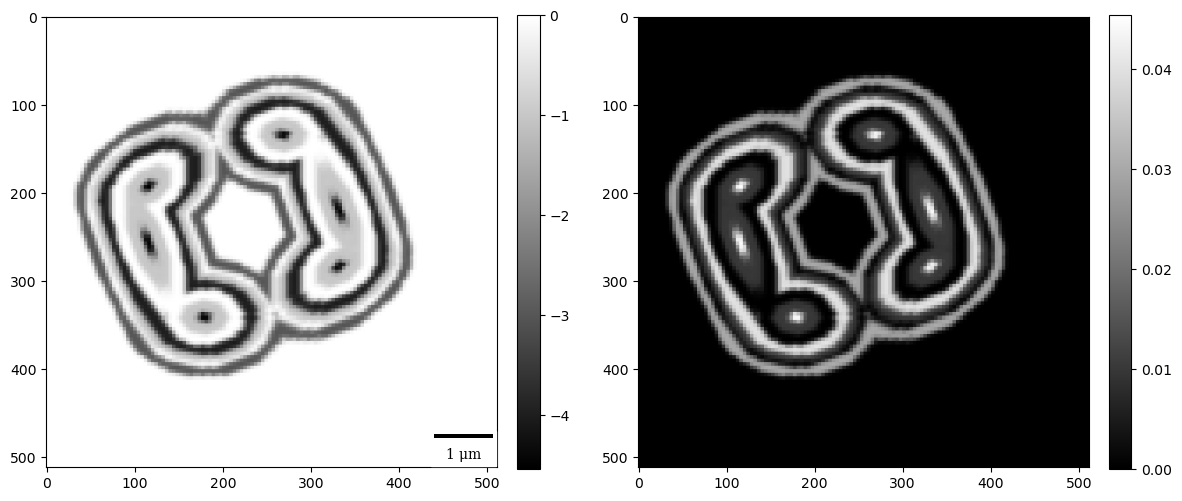

In [4]:
print(f'Generating base cube {n}^3 ...')
obj_small = gen_object(n, 1, 1e-2)   # n × n × n

zoom_factors = (nzobj / n, nobj / n, nobj / n)
print(f'Zooming to {nzobj}×{nobj}×{nobj} with factors {zoom_factors} (order=0) ...')
obj = (ndimage.zoom(obj_small.real, zoom_factors, order=0)
       + 1j * ndimage.zoom(obj_small.imag, zoom_factors, order=0)).astype('complex64')

mshow_complex(obj[:, nobj//2], True)   # xz mid-slice
mshow_complex(obj[nzobj//2],   True)   # xy mid-slice

## Probe

Realistic amplitude and phase downloaded from the ID16A example dataset.

File ‘data/prb_id16a/prb_abs_2048.tiff’ already there; not retrieving.

File ‘data/prb_id16a/prb_phase_2048.tiff’ already there; not retrieving.



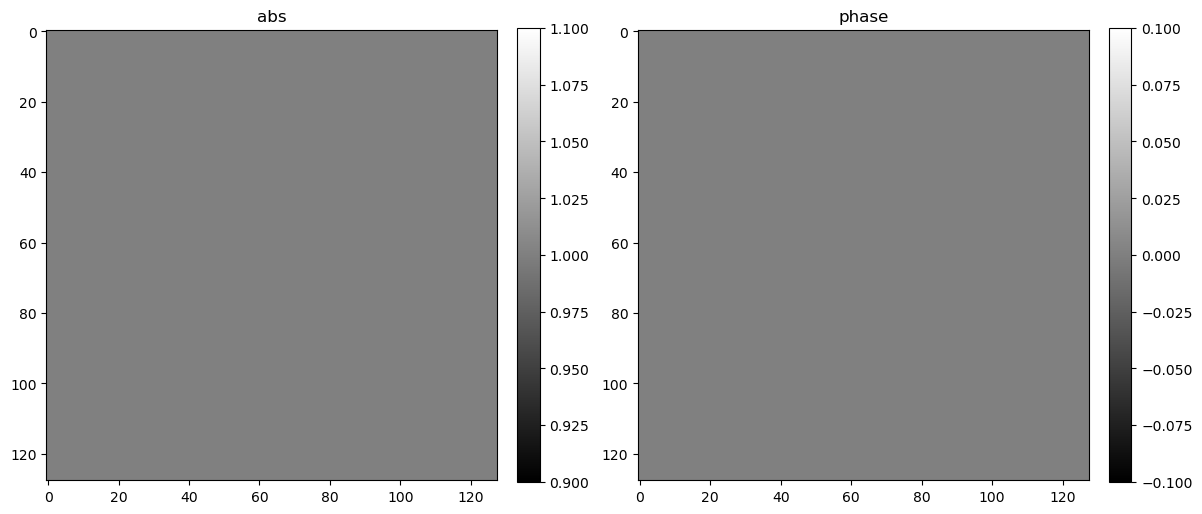

In [5]:
!wget -nc https://g-110014.fd635.8443.data.globus.org/holotomocupy/examples_synthetic/data/prb_id16a/prb_abs_2048.tiff   -P data/prb_id16a
!wget -nc https://g-110014.fd635.8443.data.globus.org/holotomocupy/examples_synthetic/data/prb_id16a/prb_phase_2048.tiff -P data/prb_id16a

prb_abs   = read_tiff('data/prb_id16a/prb_abs_2048.tiff')[:ndist]
prb_phase = read_tiff('data/prb_id16a/prb_phase_2048.tiff')[:ndist]
prb = (prb_abs * np.exp(1j * prb_phase)).astype('complex64')
prb = prb[:, prb.shape[1]//2-n//2:prb.shape[1]//2+n//2,
              prb.shape[2]//2-n//2:prb.shape[2]//2+n//2]

v = np.arange(-n//2, n//2, dtype=np.float32) / n
vx, vy = np.meshgrid(v, v, indexing='ij')
filt = np.fft.fftshift(np.exp(-4.0 * (vx*vx + vy*vy)).astype(np.float32))
prb  = ifft2(fft2(prb) * filt)
prb /= np.mean(np.abs(prb), axis=(1, 2))[:, None, None]
prb[:]=1
mshow_polar(prb[0], True)

## Angles

900 equally-spaced angles over [0, π] — same for all three scans.

In [6]:
theta = np.linspace(0, np.pi, ntheta, dtype='float32')

## Initialise Rec

One `Rec` object is shared across all three scans.
Only `vars['pos']` (the rotation-axis shift) changes between scans.

In [7]:
args = SimpleNamespace()

args.energy                  = energy
args.detector_pixelsize      = detector_pixelsize
args.focustodetectordistance = focustodetectordistance
args.z1                      = z1
args.theta                   = theta
args.ndist                   = ndist
args.ntheta                  = ntheta
args.nz                      = n
args.n                       = n
args.nzobj                   = nzobj
args.nobj                    = nobj
args.obj_dtype               = 'complex64'
args.mask                    = 0.9
args.lam_prbfit              = 0.0
args.rho                     = [1, 0.05, 0.02]
args.niter                   = 1
args.nchunk                  = 4
args.vis_step                = 1
args.err_step                = 1
args.start_iter              = 0
args.comm                    = MPI.COMM_WORLD

cl = Rec(args)

# Ground-truth object and probe (shared for all scans)
cl.vars['obj'][:] = obj
cl.vars['prb'][:] = cp.array(prb)

## Generate Data for Each Scan

For scan *k* the rotation axis is displaced by `axis_shifts[k]` pixels horizontally.
This is encoded as a constant offset in `pos[:, :, 1]` (horizontal component).
Sub-pixel noise (±0.5 px) is added to simulate sample instability.

In [8]:
# Reference flat field — same for all scans (probe only)
cl.gen_sqrt_ref(cl.vars['prb'], cl.ref)

In [9]:
for k, (ax_shift, label) in enumerate(zip(axis_shifts, scan_labels)):
    print(f'Generating scan "{label}"  (axis shift {ax_shift:+.1f} px) ...')

    # Constant horizontal axis offset + sub-pixel noise
    np.random.seed(k)
    pos_random = (np.random.random([ntheta, ndist, 2]).astype('float32') - 0.5)*n/10
    pos_k = np.zeros([ntheta, ndist, 2], dtype='float32')
    pos_k[:, :, 1] = ax_shift
    pos_k += pos_random

    cl.vars['pos'][:] = cp.array(pos_k)

    # Effective demagnification: 1 / norm_magnification per distance
    cl.eff_demagnifications[:] = 1.0 / cp.array(cl.norm_magnifications[None, :])

    cl.gen_sqrt_data(cl.vars, cl.data)

    with h5py.File(f'data/{label}.h5', 'w') as f:
        f.create_dataset('data',  data=cl.data,      compression='gzip')
        f.create_dataset('ref',   data=cl.ref.get(), compression='gzip')
        f.create_dataset('pos',   data=pos_k,        compression='gzip')
        f.create_dataset('theta', data=theta)
        f.attrs['axis_shift_px'] = float(ax_shift)
        f.attrs['n']             = n
        f.attrs['nobj']          = nobj
        f.attrs['nzobj']         = nzobj
    print(f'  saved data/{label}.h5')

Generating scan "left"  (axis shift -115.2 px) ...
  saved data/left.h5
Generating scan "center"  (axis shift +0.0 px) ...
  saved data/center.h5
Generating scan "right"  (axis shift +115.2 px) ...
  saved data/right.h5


## Visualise

First projection (angle 0, distance 0) and the flat-field reference for each scan.

--- left ---


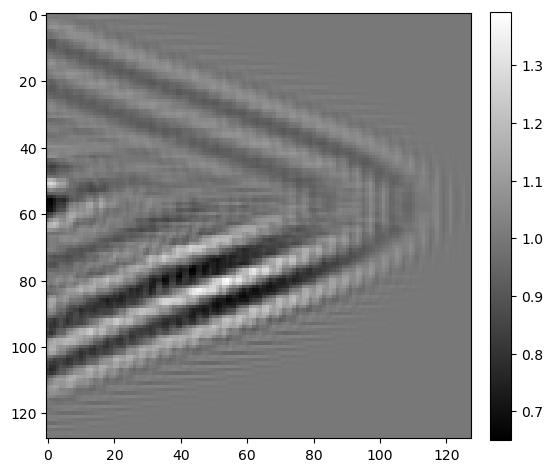

--- center ---


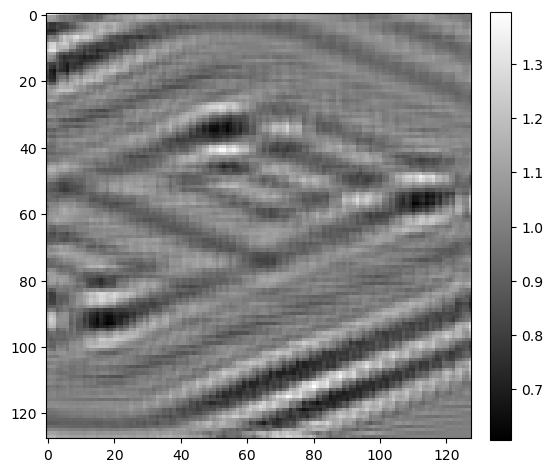

--- right ---


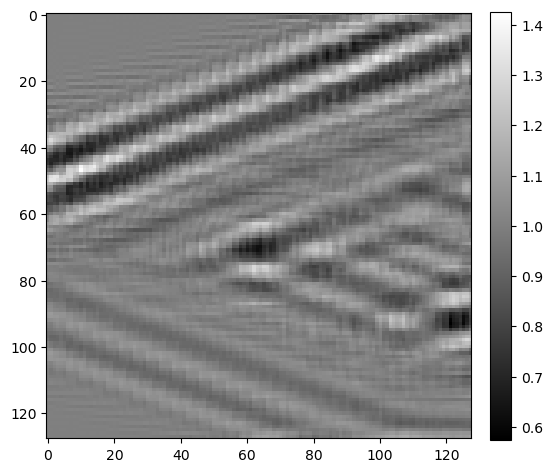

In [10]:
for label in scan_labels:
    with h5py.File(f'data/{label}.h5', 'r') as f:
        proj0 = f['data'][0, 0]   # angle 0, distance 0
    print(f'--- {label} ---')
    mshow(proj0, True)